In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate bitsandbytes scikit-learn pandas numpy matplotlib seaborn datasets huggingface_hub

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch
import transformers
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Transformers version:", transformers.__version__)

# Verify GPU works with a simple op
if torch.cuda.is_available():
    x = torch.randn(3, 3).cuda().half()
    y = x @ x
    print("GPU float16 test: OK")
    print("GPU:", torch.cuda.get_device_name(0))

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.4 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
Transformers version: 5.10.0.dev0
GPU float16 test: OK
GPU: Tesla T4


In [2]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
MODEL_NAME  = "Qwen/Qwen3.5-4B"
NOTEBOOK_ID = "qwen3.5-4B"

LABELS    = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]
LABEL2INT = {l: i for i, l in enumerate(LABELS)}

MAX_NEW_TOKENS = 256
TEMPERATURE    = 0.0
TOP_P          = 1.0

print("Model:", MODEL_NAME)
print("Labels:", LABELS)

Model: Qwen/Qwen3.5-4B
Labels: ['Ambivalent', 'Clear Reply', 'Clear Non-Reply']


In [4]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

raw = load_dataset("ailsntua/QEvasion")

train_full = raw["train"].to_pandas()
test_df    = raw["test"].to_pandas()

for df in [train_full, test_df]:
    df.columns = df.columns.str.strip().str.lower()

train_full = train_full.rename(columns={"interview_answer": "answer", "clarity_label": "label"})
test_df    = test_df.rename(columns={"interview_answer": "answer", "clarity_label": "label"})

train_full = train_full.dropna(subset=["question", "answer", "label"]).reset_index(drop=True)
test_df    = test_df.dropna(subset=["question", "answer"]).reset_index(drop=True)

# Split train_full → train_df (for few-shot selection) + val_full (for subset sampling)
train_df, val_full = train_test_split(
    train_full, test_size=0.15, random_state=SEED, stratify=train_full["label"]
)
train_df = train_df.reset_index(drop=True)
val_full = val_full.reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_full:", val_full.shape)
print("test_df: ", test_df.shape)
print("\nLabel distribution (train_df):\n", train_df["label"].value_counts())

README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

train_df: (2930, 20)
val_full: (518, 20)
test_df:  (308, 20)

Label distribution (train_df):
 label
Ambivalent         1734
Clear Reply         894
Clear Non-Reply     302
Name: count, dtype: int64


In [5]:
# Stratified 90-sample subset for fast evaluation (30 per class)
EVAL_N_PER_CLASS = 30

def make_stratified_subset(df, n_per_class, seed=SEED):
    subsets = []
    for label in LABELS:
        class_df = df[df["label"] == label]
        n = min(n_per_class, len(class_df))
        subsets.append(class_df.sample(n, random_state=seed))
    return pd.concat(subsets).sample(frac=1, random_state=seed).reset_index(drop=True)

val_subset = make_stratified_subset(val_full, n_per_class=EVAL_N_PER_CLASS)

print("val_subset size:", len(val_subset))
print(val_subset["label"].value_counts())

# Representativeness check
print("\nClass proportions:")
for label in LABELS:
    full_pct   = (val_full["label"] == label).mean() * 100
    subset_pct = (val_subset["label"] == label).mean() * 100
    print(f"  {label:20s}  full={full_pct:.1f}%  subset={subset_pct:.1f}%")

val_subset size: 90
label
Clear Reply        30
Ambivalent         30
Clear Non-Reply    30
Name: count, dtype: int64

Class proportions:
  Ambivalent            full=59.1%  subset=33.3%
  Clear Reply           full=30.5%  subset=33.3%
  Clear Non-Reply       full=10.4%  subset=33.3%


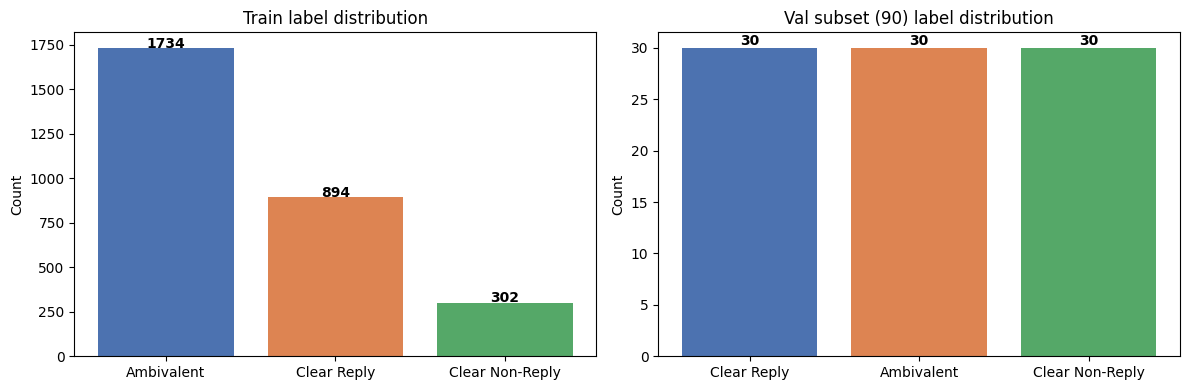

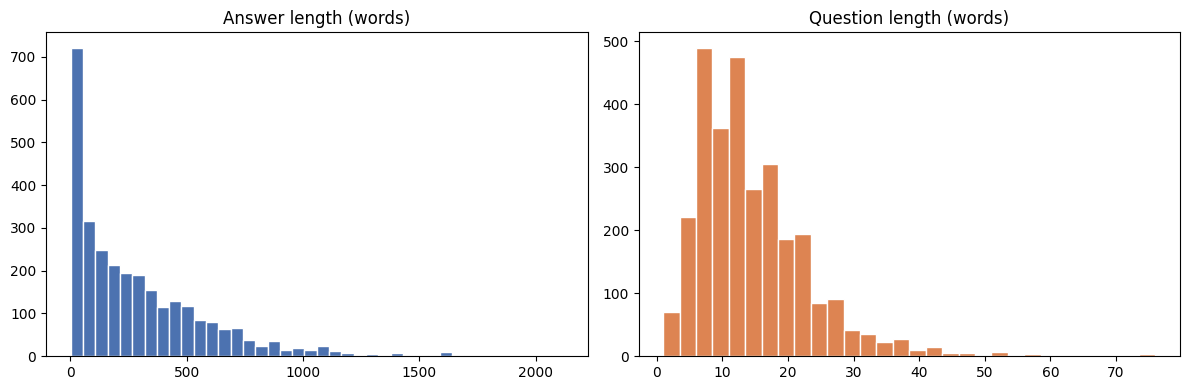

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Val subset (90)", val_subset)]):
    counts = df["label"].value_counts()
    ax.bar(counts.index, counts.values, color=["#4C72B0","#DD8452","#55A868"])
    ax.set_title(f"{name} label distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_label_distribution.png", dpi=150)
plt.show()

train_df["answer_len"]   = train_df["answer"].str.split().str.len()
train_df["question_len"] = train_df["question"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["answer_len"],   bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Answer length (words)")
axes[1].hist(train_df["question_len"], bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Question length (words)")
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_length_distribution.png", dpi=150)
plt.show()

In [7]:
import gc

if "model" in globals():
    del model, tokenizer
    gc.collect()

print(f"Loading {MODEL_NAME} ...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="cuda:0", 
    trust_remote_code=True,
)
model = model.to(DEVICE)
model.eval()

print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")
print("Device:", next(model.parameters()).device)
print("Chat template exists:", getattr(tokenizer, "chat_template", None) is not None)

Loading Qwen/Qwen3.5-4B ...


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Parameters: 4205.751296 M
Device: cuda:0
Chat template exists: True


In [8]:
# # FIND GOOD FEW-SHOT EXAMPLES FROM YOUR ACTUAL TRAIN SET
# import pandas as pd
# import random
# from datasets import load_dataset
# from sklearn.model_selection import train_test_split

# SEED   = 42
# LABELS = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]

# # Reload data if not in memory
# raw      = load_dataset("ailsntua/QEvasion")
# train_df = raw["train"].to_pandas()
# test_df  = raw["test"].to_pandas()

# for df in [train_df, test_df]:
#     df.columns = df.columns.str.strip().str.lower()

# train_df = train_df.rename(columns={"interview_answer": "answer", "clarity_label": "label"})
# train_df = train_df.dropna(subset=["question", "answer", "label"]).reset_index(drop=True)

# train_df, val_subset = train_test_split(
#     train_df, test_size=0.15, random_state=SEED, stratify=train_df["label"]
# )
# train_df = train_df.reset_index(drop=True)

# # Find better few-shot examples — skip very short AND very long answers

# for label in LABELS:
#     print(f"\n{'='*60}")
#     print(f"  Label: {label}")
#     print(f"{'='*60}")
#     subset = train_df[train_df["label"] == label].copy()
#     subset["answer_len"] = subset["answer"].str.split().str.len()
#     # Filter: between 20 and 80 words — long enough to be meaningful, short enough to be clear
#     subset = subset[
#         (subset["answer_len"] >= 20) &
#         (subset["answer_len"] <= 80)
#     ].sort_values("answer_len")
#     for _, row in subset.head(5).iterrows():
#         print(f"\n  Q: {row['question']}")
#         print(f"  A: {row['answer']}")
#         print(f"  Words: {row['answer_len']}")
#         print()

In [9]:
SYSTEM_PROMPT = (
    "You are a political communication analyst. "
    "Classify the politician's answer to the question as exactly one of:\n"
    "  - Clear Reply: directly and clearly answers the question.\n"
    "  - Ambivalent: vague, partial, or evasive.\n"
    "  - Clear Non-Reply: completely avoids answering.\n"
    "Respond with ONLY the label. Nothing else."
)

SYSTEM_PROMPT_COT = (
    "You are a political communication analyst. "
    "Classify the politician's answer as one of:\n"
    "  - Clear Reply\n  - Ambivalent\n  - Clear Non-Reply\n"
    "Think step by step, then write: LABEL: <your label>"
)

def build_zero_shot_messages(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nClassification:"}
    ]

def build_few_shot_messages(question, answer, examples):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for ex in examples:
        messages.append({"role": "user",
            "content": f"Question: {ex['question']}\nAnswer: {ex['answer']}\n\nClassification:"})
        messages.append({"role": "assistant", "content": ex["label"]})
    messages.append({"role": "user",
        "content": f"Question: {question}\nAnswer: {answer}\n\nClassification:"})
    return messages

def build_cot_messages(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT_COT},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nReasoning and label:"}
    ]

print("Prompt builders defined.")

Prompt builders defined.


In [10]:
def build_plain_prompt(messages):
    parts = []
    for msg in messages:
        if msg["role"] == "system":
            parts.append(msg["content"])
        elif msg["role"] == "user":
            parts.append(f"User: {msg['content']}")
        elif msg["role"] == "assistant":
            parts.append(f"Assistant: {msg['content']}")
    parts.append("Assistant:")
    return "\n\n".join(parts)


def generate_response(messages, max_new_tokens=15, temperature=TEMPERATURE, top_p=TOP_P):
    try:
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
    except Exception:
        text = build_plain_prompt(messages)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    try:
        device = next(model.parameters()).device
    except Exception:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    input_len = inputs["input_ids"].shape[1]
    new_ids   = output_ids[0][input_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


def parse_label(text):
    if not text or not text.strip():
        return "Unknown"
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    if not text:
        return "Unknown"
    # CoT: extract after LABEL:
    cot = re.search(r"LABEL\s*:\s*(.+)", text, re.IGNORECASE)
    if cot:
        text = cot.group(1)
    t = text.lower().strip()
    if "clear non-reply" in t or "non-reply" in t or "non reply" in t:
        return "Clear Non-Reply"
    if "clear reply" in t:
        return "Clear Reply"
    if "ambivalent" in t or "ambiguous" in t:
        return "Ambivalent"
    if "reply" in t:
        return "Clear Reply"
    return "Unknown"


def run_inference(df, prompt_builder, max_new_tokens=15, temperature=TEMPERATURE):
    results = []
    invalid = 0
    for _, row in df.iterrows():
        messages = prompt_builder(row["question"], row["answer"])
        raw      = generate_response(messages, max_new_tokens=max_new_tokens)
        label    = parse_label(raw)
        if label == "Unknown":
            invalid += 1
        results.append({"raw_output": raw, "predicted_label": label})
        if len(results) % 30 == 0:
            print(f"  {len(results)}/{len(df)} done | invalid: {invalid}")

    out = df.copy().reset_index(drop=True)
    out["raw_output"]      = [r["raw_output"]      for r in results]
    out["predicted_label"] = [r["predicted_label"] for r in results]
    print(f"Done. Invalid: {invalid}/{len(df)} ({100*invalid/len(df):.1f}%)")
    return out


def run_self_consistency(df, prompt_builder, n_samples=3, temperature=0.7):
    results = []
    for _, row in df.iterrows():
        messages = prompt_builder(row["question"], row["answer"])
        votes = []
        for _ in range(n_samples):
            raw   = generate_response(messages, max_new_tokens=15, temperature=temperature)
            label = parse_label(raw)
            if label != "Unknown":
                votes.append(label)
        predicted = Counter(votes).most_common(1)[0][0] if votes else "Unknown"
        results.append({"predicted_label": predicted, "votes": votes})
        if len(results) % 30 == 0:
            print(f"  {len(results)}/{len(df)} done")

    out = df.copy().reset_index(drop=True)
    out["predicted_label"] = [r["predicted_label"] for r in results]
    out["votes"]           = [r["votes"]           for r in results]
    return out

print("Inference engine ready.")

Inference engine ready.


In [11]:
def evaluate(df, strategy_name):
    n_inv   = (df["predicted_label"] == "Unknown").sum()
    n_total = len(df)

    # Invalids count as wrong — replace with a sentinel that never matches any true label
    y_true = df["label"].tolist()
    y_pred = df["predicted_label"].replace("Unknown", "__INVALID__").tolist()

    if n_total == 0:
        print(f"\n{'='*55}\n  {strategy_name}\n{'='*55}")
        print("  NO DATA")
        return {"strategy": strategy_name, "accuracy": 0, "macro_f1": 0,
                "weighted_f1": 0, "macro_precision": 0, "macro_recall": 0,
                "n_invalid": 0, "coverage": 0.0}

    # Score only over the 3 real label columns; __INVALID__ preds penalize recall
    acc        = accuracy_score(y_true, y_pred)
    macro_f1   = f1_score(y_true, y_pred, average="macro",    labels=LABELS, zero_division=0)
    w_f1       = f1_score(y_true, y_pred, average="weighted", labels=LABELS, zero_division=0)
    macro_prec = precision_score(y_true, y_pred, average="macro", labels=LABELS, zero_division=0)
    macro_rec  = recall_score(y_true, y_pred,    average="macro", labels=LABELS, zero_division=0)
    coverage   = (n_total - n_inv) / n_total

    print(f"\n{'='*55}\n  {strategy_name}\n{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro F1        : {macro_f1:.4f}  ← penalizes invalids")
    print(f"  Weighted F1     : {w_f1:.4f}")
    print(f"  Macro Precision : {macro_prec:.4f}")
    print(f"  Macro Recall    : {macro_rec:.4f}")
    print(f"  Coverage        : {coverage:.1%}  ({n_total - n_inv}/{n_total} valid)")
    print(f"  Invalid outputs : {n_inv}/{n_total}")
    print()

    # Classification report on valid only (for readable per-class breakdown)
    valid = df[df["predicted_label"] != "Unknown"]
    print("  Per-class breakdown (valid predictions only):")
    print(classification_report(valid["label"], valid["predicted_label"],
                                target_names=LABELS, zero_division=0))

    return {
        "strategy":        strategy_name,
        "accuracy":        acc,
        "macro_f1":        macro_f1,
        "weighted_f1":     w_f1,
        "macro_precision": macro_prec,
        "macro_recall":    macro_rec,
        "n_invalid":       int(n_inv),
        "coverage":        coverage,
    }


def plot_confusion_matrix(df, title, ax):
    # Show invalids as their own column so they're visible in the matrix
    y_true = df["label"]
    y_pred = df["predicted_label"].replace("Unknown", "__INVALID__")
    labels_with_inv = LABELS + ["__INVALID__"]

    cm = confusion_matrix(y_true, y_pred, labels=labels_with_inv)

    # Drop the __INVALID__ row (it never appears as a true label)
    cm = cm[: len(LABELS), :]

    x_labels = LABELS + ["Invalid"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=x_labels, yticklabels=LABELS, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

print("Evaluation helpers ready.")

Evaluation helpers ready.


In [12]:
# Cell 10: Few-shot example selection

def select_best_few_shot_examples(df, n_per_class=1, seed=SEED):
    rng = random.Random(seed)
    examples = []
    for label in LABELS:
        subset = df[df["label"] == label].copy()
        subset["answer_len"] = subset["answer"].str.split().str.len()
        subset = subset[
            (subset["answer_len"] >= 20) &
            (subset["answer_len"] <= 80)
        ].sort_values("answer_len")
        pool   = subset.head(20).to_dict("records")
        chosen = rng.sample(pool, min(n_per_class, len(pool)))
        for ex in chosen:
            examples.append({
                "question": ex["question"],
                "answer":   ex["answer"],
                "label":    label
            })
    return examples

# Pre-compute all three shot counts
FS_EXAMPLES_1 = select_best_few_shot_examples(train_df, n_per_class=1)
FS_EXAMPLES_2 = select_best_few_shot_examples(train_df, n_per_class=2)
FS_EXAMPLES_3 = select_best_few_shot_examples(train_df, n_per_class=3)

print("Few-shot examples selected:")
for k, exs in [("1-per-class (3 total)", FS_EXAMPLES_1),
               ("2-per-class (6 total)", FS_EXAMPLES_2),
               ("3-per-class (9 total)", FS_EXAMPLES_3)]:
    print(f"\n  {k}:")
    for ex in exs:
        print(f"    [{ex['label']}] Q: {ex['question'][:60]}")
        print(f"              A: {ex['answer'][:80]}")

def build_few_shot_messages(question, answer, examples):
    messages = [{"role": "system", "content": SYSTEM_PROMPT_FORMAL}]
    for ex in examples:
        messages.append({"role": "user",
            "content": f"Question: {ex['question']}\nAnswer: {ex['answer']}\n\nClassification:"})
        messages.append({"role": "assistant", "content": ex["label"]})
    messages.append({"role": "user",
        "content": f"Question: {question}\nAnswer: {answer}\n\nClassification:"})
    return messages

print("\nFew-shot builder ready.")
print("Inference will run on:", len(val_subset), "samples")

Few-shot examples selected:

  1-per-class (3 total):
    [Ambivalent] Q: Can you give me your timetable?
              A: Steve, what do you think? Within the next week or two, we think the States will 
    [Clear Reply] Q:  What is your reaction?
              A: It's heartbreaking. It's heartbreaking, and I think that anybody who sees it kno
    [Clear Non-Reply] Q: Is there a transcript of your conversation, your private con
              A: Mike, do they have a transcript? They probably have a rough transcript, which yo

  2-per-class (6 total):
    [Ambivalent] Q: Can you give me your timetable?
              A: Steve, what do you think? Within the next week or two, we think the States will 
    [Ambivalent] Q: Does it relate to the policy that you're going to unveil tha
              A: It relates to everything we're doing. And you'll be hearing about it in—over the
    [Clear Reply] Q:  Will you commit to allowing journalists to have access to t
              A: I will commit w

In [13]:
print("Inference will run on:", len(val_subset), "samples")

Inference will run on: 90 samples


In [14]:
# Cell 11: All experiment definitions

# ── Prompt wording variants ──────────────────────────────────────
SYSTEM_PROMPT_MINIMAL = (
    "Classify the answer as: Clear Reply, Ambivalent, or Clear Non-Reply. "
    "Reply with the label only."
)

SYSTEM_PROMPT_FORMAL = (
    "You are a political communication analyst. "
    "Classify the politician's answer to the question as exactly one of:\n"
    "  - Clear Reply: directly and clearly answers the question.\n"
    "  - Ambivalent: vague, partial, or evasive.\n"
    "  - Clear Non-Reply: completely avoids answering.\n"
    "Respond with ONLY the label. Nothing else."
)

SYSTEM_PROMPT_COT_SHORT = (
    "You are a political communication analyst. "
    "Classify the politician's answer as one of:\n"
    "  - Clear Reply\n  - Ambivalent\n  - Clear Non-Reply\n"
    "Give one sentence of reasoning, then write: LABEL: <label>"
)

SYSTEM_PROMPT_COT_LONG = (
    "You are a political communication analyst. "
    "Classify the politician's answer as one of:\n"
    "  - Clear Reply\n  - Ambivalent\n  - Clear Non-Reply\n"
    "Think step by step about whether the politician directly answers, "
    "evades, or is vague. Then write: LABEL: <label>"
)

# ── Prompt builders ──────────────────────────────────────────────
def zeroshot_formal(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT_FORMAL},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nClassification:"}
    ]

def zeroshot_minimal(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT_MINIMAL},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nLabel:"}
    ]

def fewshot_1per_class(question, answer):
    return build_few_shot_messages(question, answer, FS_EXAMPLES_1)

def fewshot_2per_class(question, answer):
    return build_few_shot_messages(question, answer, FS_EXAMPLES_2)

def fewshot_3per_class(question, answer):
    return build_few_shot_messages(question, answer, FS_EXAMPLES_3)

def cot_short(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT_COT_SHORT},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nReasoning and label:"}
    ]

def cot_long(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT_COT_LONG},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nReasoning and label:"}
    ]

def cot_with_fewshot(question, answer):
    COT_DEMOS = [
        {
            "question": "Will you raise the minimum wage?",
            "answer":   "Yes, we will raise it to fifteen dollars by 2026.",
            "reasoning": "The politician gives a direct yes with a specific amount and date.",
            "label":    "Clear Reply"
        },
        {
            "question": "Do you support the immigration bill?",
            "answer":   "Immigration is a very complex issue with many perspectives.",
            "reasoning": "The answer is vague and takes no clear position on the bill.",
            "label":    "Ambivalent"
        },
        {
            "question": "Did you approve the wiretapping?",
            "answer":   "What I can say is that we are fully committed to the rule of law.",
            "reasoning": "The politician deflects entirely and never addresses the question.",
            "label":    "Clear Non-Reply"
        },
    ]
    messages = [{"role": "system", "content": SYSTEM_PROMPT_COT_SHORT}]
    for ex in COT_DEMOS:
        messages.append({"role": "user", "content":
            f"Question: {ex['question']}\nAnswer: {ex['answer']}\n\nReasoning and label:"})
        messages.append({"role": "assistant", "content":
            f"{ex['reasoning']}\nLABEL: {ex['label']}"})
    messages.append({"role": "user", "content":
        f"Question: {question}\nAnswer: {answer}\n\nReasoning and label:"})
    return messages

def fewshot_cot_long(question, answer):
    """CoT long reasoning with few-shot demonstrations."""
    COT_DEMOS_LONG = [
        {
            "question": "Will you raise the minimum wage?",
            "answer":   "Yes, we will raise it to fifteen dollars by 2026.",
            "reasoning": (
                "The question asks directly about raising the minimum wage. "
                "The politician says 'Yes' and gives a specific figure and timeline. "
                "There is no hedging or deflection. This is a direct, complete answer."
            ),
            "label": "Clear Reply"
        },
        {
            "question": "Do you support the immigration bill?",
            "answer":   "Immigration is a very complex issue with many perspectives to consider.",
            "reasoning": (
                "The question asks for a yes/no stance on the bill. "
                "The politician does not say yes or no, instead calling it 'complex'. "
                "This is evasive — they acknowledge the topic but give no position."
            ),
            "label": "Ambivalent"
        },
        {
            "question": "Did you approve the wiretapping?",
            "answer":   "What I can say is that we are fully committed to the rule of law.",
            "reasoning": (
                "The question is a direct yes/no about approving wiretapping. "
                "The politician completely ignores it and talks about rule of law instead. "
                "There is zero engagement with the actual question asked."
            ),
            "label": "Clear Non-Reply"
        },
    ]
    messages = [{"role": "system", "content": SYSTEM_PROMPT_COT_LONG}]
    for ex in COT_DEMOS_LONG:
        messages.append({"role": "user", "content":
            f"Question: {ex['question']}\nAnswer: {ex['answer']}\n\nReasoning and label:"})
        messages.append({"role": "assistant", "content":
            f"{ex['reasoning']}\nLABEL: {ex['label']}"})
    messages.append({"role": "user", "content":
        f"Question: {question}\nAnswer: {answer}\n\nReasoning and label:"})
    return messages

# ── Master experiment list ───────────────────────────────────────
# (name, builder, max_new_tokens, is_self_consistency, n_sc_samples)
EXPERIMENTS = [
    # Zero-shot variants
    ("ZeroShot-Formal",      zeroshot_formal,    15,  False, None),
    ("ZeroShot-Minimal",     zeroshot_minimal,   15,  False, None),
    # Few-shot: shot count ablation
    ("FewShot-1perClass",    fewshot_1per_class, 15,  False, None),
    ("FewShot-2perClass",    fewshot_2per_class, 15,  False, None),
    ("FewShot-3perClass",    fewshot_3per_class, 15,  False, None),
    # CoT variants
    ("CoT-Short",            cot_short,          100, False, None),
    ("CoT-Long",             cot_long,           200, False, None),
    ("CoT-FewShot-Short",    cot_with_fewshot,   100, False, None),
    ("CoT-FewShot-Long",     fewshot_cot_long,   200, False, None),
    # Self-consistency: vote count ablation
    ("SelfCons-n3",          zeroshot_formal,    15,  True,  3),
    ("SelfCons-n5",          zeroshot_formal,    15,  True,  5),
    ("SelfCons-n7",          zeroshot_formal,    15,  True,  7),
    # Self-consistency on best few-shot
    ("SelfCons-FS-n5",       fewshot_1per_class, 15,  True,  5),
]

print(f"Total experiments: {len(EXPERIMENTS)}")
print(f"{'─'*50}")
for name, _, max_tok, is_sc, n_sc in EXPERIMENTS:
    sc_note = f" (votes={n_sc})" if is_sc else ""
    print(f"  {name:25s} max_tokens={max_tok}{sc_note}")

Total experiments: 13
──────────────────────────────────────────────────
  ZeroShot-Formal           max_tokens=15
  ZeroShot-Minimal          max_tokens=15
  FewShot-1perClass         max_tokens=15
  FewShot-2perClass         max_tokens=15
  FewShot-3perClass         max_tokens=15
  CoT-Short                 max_tokens=100
  CoT-Long                  max_tokens=200
  CoT-FewShot-Short         max_tokens=100
  CoT-FewShot-Long          max_tokens=200
  SelfCons-n3               max_tokens=15 (votes=3)
  SelfCons-n5               max_tokens=15 (votes=5)
  SelfCons-n7               max_tokens=15 (votes=7)
  SelfCons-FS-n5            max_tokens=15 (votes=5)


In [15]:
# DIAGNOSTIC: See raw output from 4B model before running all experiments
test_messages = zeroshot_formal(
    val_subset.iloc[0]["question"],
    val_subset.iloc[0]["answer"]
)
raw = generate_response(test_messages, max_new_tokens=50)
print("RAW OUTPUT:")
print(repr(raw))
print()
print("PARSED:", parse_label(raw))

RAW OUTPUT:
'Clear Reply'

PARSED: Clear Reply


In [16]:
# Cell 12: Run all experiments on val_subset

all_results = {}
all_metrics = {}

for exp_name, builder, max_tok, is_sc, n_sc in EXPERIMENTS:
    print(f"\n{'─'*55}")
    print(f"  Running: {exp_name}")
    print(f"{'─'*55}")

    if is_sc:
        df_res = run_self_consistency(
            val_subset, builder, n_samples=n_sc, temperature=0.7
        )
        df_res["raw_output"] = ""
    else:
        df_res = run_inference(val_subset, builder, max_new_tokens=max_tok)

    metrics = evaluate(df_res, exp_name)
    all_results[exp_name] = df_res
    all_metrics[exp_name] = metrics

print("\n\nAll experiments complete.")


───────────────────────────────────────────────────────
  Running: ZeroShot-Formal
───────────────────────────────────────────────────────
  30/90 done | invalid: 5
  60/90 done | invalid: 6
  90/90 done | invalid: 9
Done. Invalid: 9/90 (10.0%)

  ZeroShot-Formal
  Accuracy        : 0.4222
  Macro F1        : 0.4430  ← penalizes invalids
  Weighted F1     : 0.4430
  Macro Precision : 0.4814
  Macro Recall    : 0.4222
  Coverage        : 90.0%  (81/90 valid)
  Invalid outputs : 9/90

  Per-class breakdown (valid predictions only):
                 precision    recall  f1-score   support

     Ambivalent       0.32      0.44      0.37        25
    Clear Reply       0.50      0.32      0.39        28
Clear Non-Reply       0.62      0.64      0.63        28

       accuracy                           0.47        81
      macro avg       0.48      0.47      0.47        81
   weighted avg       0.49      0.47      0.47        81


───────────────────────────────────────────────────────
  Ru

In [17]:
# Cell 13: Master results table

master_df = pd.DataFrame(list(all_metrics.values())).set_index("strategy")
master_df = master_df.sort_values("macro_f1", ascending=False)

print(f"\n{'='*70}")
print(f"  MASTER RESULTS — {MODEL_NAME}")
print(f"{'='*70}")
print(master_df[["accuracy","macro_f1","weighted_f1",
                  "macro_precision","macro_recall","n_invalid"]].to_string())

best_exp_name = master_df.index[0]
print(f"\n  Best : {best_exp_name}")
print(f"  Macro F1 : {master_df.loc[best_exp_name,'macro_f1']:.4f}")


  MASTER RESULTS — Qwen/Qwen3.5-4B
                   accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  n_invalid
strategy                                                                                    
CoT-Short          0.533333  0.525004     0.525004         0.544077      0.533333          9
SelfCons-FS-n5     0.500000  0.512883     0.512883         0.570612      0.500000         12
FewShot-1perClass  0.500000  0.512883     0.512883         0.570612      0.500000         12
FewShot-3perClass  0.355556  0.446450     0.446450         0.621744      0.355556         37
ZeroShot-Formal    0.422222  0.442973     0.442973         0.481406      0.422222          9
SelfCons-n7        0.422222  0.442973     0.442973         0.481406      0.422222          9
SelfCons-n5        0.422222  0.442973     0.442973         0.481406      0.422222          9
SelfCons-n3        0.422222  0.442973     0.442973         0.481406      0.422222          9
FewShot-2perClass  0.388889  0.440

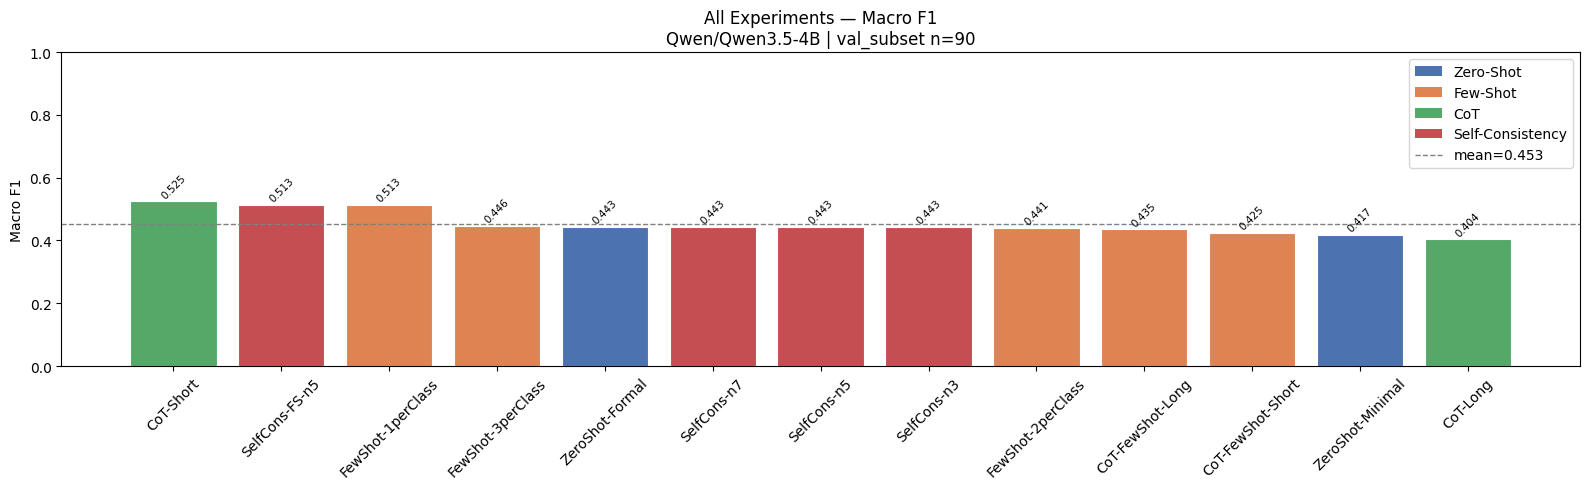

In [18]:
# Cell 14: Bar chart — Macro F1 all experiments

fig, ax = plt.subplots(figsize=(16, 5))

colors_bar = []
for n in master_df.index:
    if "ZeroShot" in n:      colors_bar.append("#4C72B0")
    elif "FewShot" in n:     colors_bar.append("#DD8452")
    elif "CoT" in n:         colors_bar.append("#55A868")
    elif "SelfCons" in n:    colors_bar.append("#C44E52")
    else:                    colors_bar.append("#8172B2")

bars = ax.bar(master_df.index, master_df["macro_f1"],
              color=colors_bar, edgecolor="white", linewidth=0.8)
ax.set_ylabel("Macro F1")
ax.set_title(f"All Experiments — Macro F1\n{MODEL_NAME} | val_subset n={len(val_subset)}")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)
ax.axhline(y=master_df["macro_f1"].mean(), color="gray",
           linestyle="--", linewidth=1, label=f"mean={master_df['macro_f1'].mean():.3f}")

for bar, val in zip(bars, master_df["macro_f1"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=7.5, rotation=45)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#4C72B0", label="Zero-Shot"),
    Patch(facecolor="#DD8452", label="Few-Shot"),
    Patch(facecolor="#55A868", label="CoT"),
    Patch(facecolor="#C44E52", label="Self-Consistency"),
] + [ax.get_legend_handles_labels()[0][-1]], loc="upper right")

plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_all_experiments_macro_f1.png", dpi=150)
plt.show()

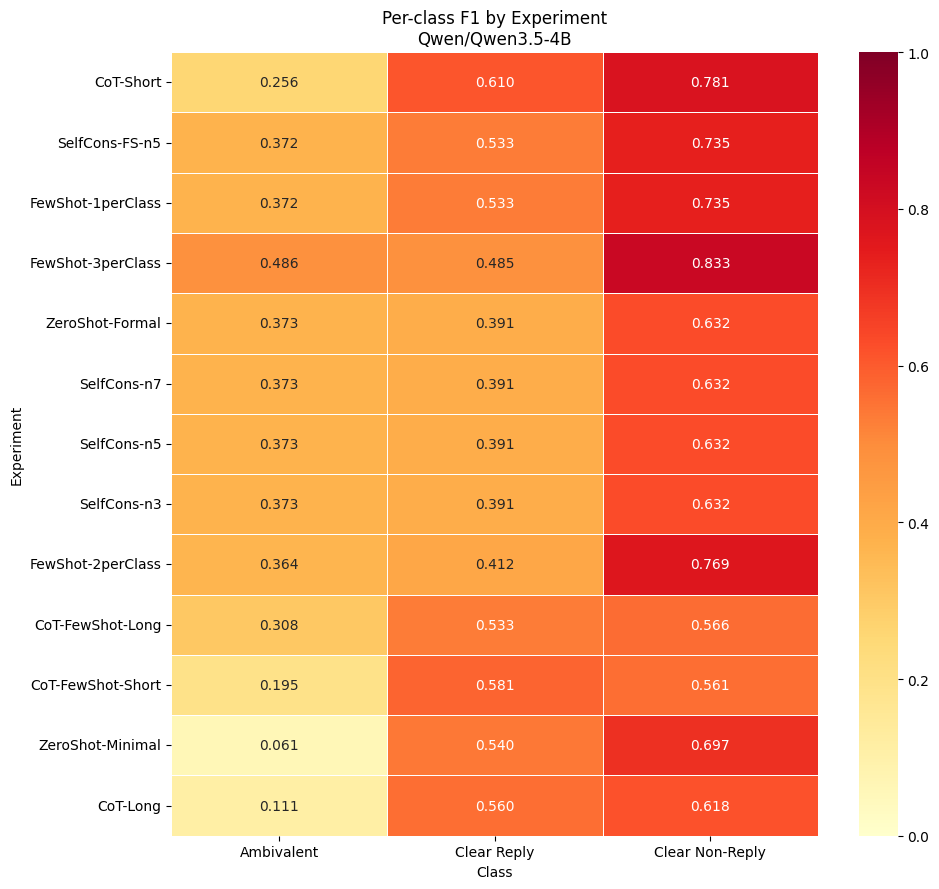

In [19]:
# Cell 15: Per-class F1 heatmap

report_data = {}
for exp_name, df_res in all_results.items():
    valid = df_res[df_res["predicted_label"] != "Unknown"]
    if len(valid) == 0:
        continue
    rep = classification_report(
        valid["label"], valid["predicted_label"],
        target_names=LABELS, output_dict=True, zero_division=0
    )
    report_data[exp_name] = {lbl: rep[lbl]["f1-score"] for lbl in LABELS}

heatmap_df = pd.DataFrame(report_data).T
heatmap_df = heatmap_df.reindex(master_df.index)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(f"Per-class F1 by Experiment\n{MODEL_NAME}")
ax.set_xlabel("Class")
ax.set_ylabel("Experiment")
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_perclass_f1_heatmap.png", dpi=150)
plt.show()

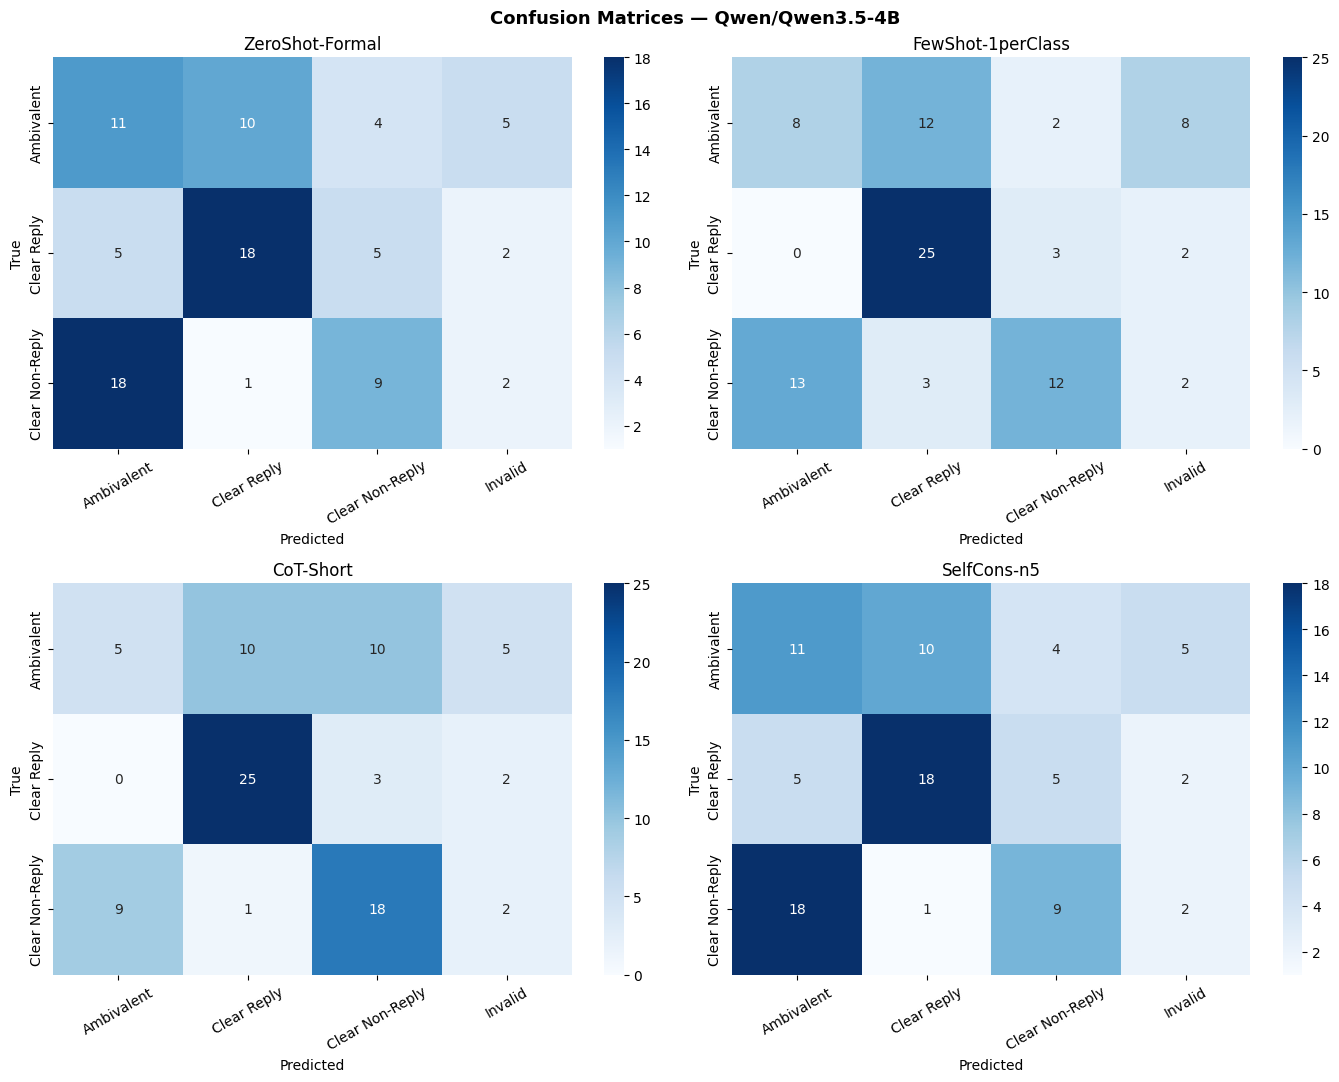

In [20]:
# Cell 16: Confusion matrices — core 4 strategies

core = ["ZeroShot-Formal", "FewShot-1perClass", "CoT-Short", "SelfCons-n5"]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, exp_name in zip(axes, core):
    if exp_name in all_results:
        plot_confusion_matrix(all_results[exp_name], exp_name, ax)

plt.suptitle(f"Confusion Matrices — {MODEL_NAME}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_confusion_matrices.png", dpi=150)
plt.show()

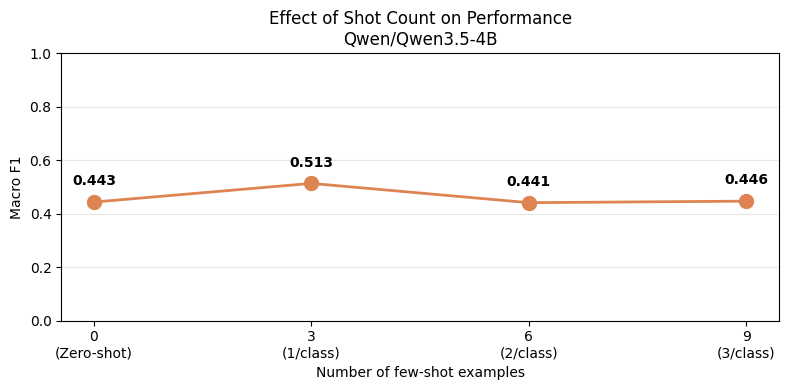

In [21]:
# Cell 17: Effect of shot count on Macro F1

shot_map = {
    "ZeroShot-Formal":   0,
    "FewShot-1perClass": 3,
    "FewShot-2perClass": 6,
    "FewShot-3perClass": 9,
}

x_labels = ["0\n(Zero-shot)", "3\n(1/class)", "6\n(2/class)", "9\n(3/class)"]
y_vals   = [master_df.loc[n, "macro_f1"] if n in master_df.index else 0
            for n in shot_map.keys()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_labels, y_vals, marker="o", linewidth=2,
        color="#DD8452", markersize=10)
for x, y in zip(x_labels, y_vals):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Number of few-shot examples")
ax.set_ylabel("Macro F1")
ax.set_title(f"Effect of Shot Count on Performance\n{MODEL_NAME}")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_shot_count_effect.png", dpi=150)
plt.show()

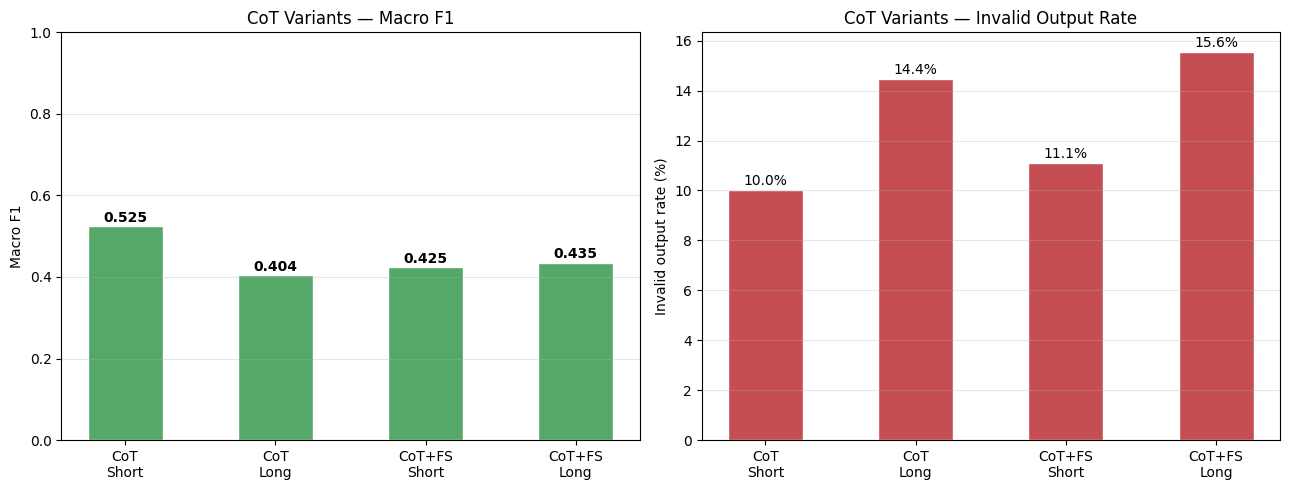

In [22]:
# Cell 18: CoT variants comparison

cot_names  = ["CoT-Short", "CoT-Long", "CoT-FewShot-Short", "CoT-FewShot-Long"]
cot_labels = ["CoT\nShort", "CoT\nLong", "CoT+FS\nShort", "CoT+FS\nLong"]
cot_f1     = [master_df.loc[n, "macro_f1"] if n in master_df.index else 0
              for n in cot_names]
cot_inv    = [all_metrics[n]["n_invalid"] / len(val_subset) * 100
              if n in all_metrics else 0
              for n in cot_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(cot_labels, cot_f1, color="#55A868", edgecolor="white", width=0.5)
axes[0].set_ylabel("Macro F1")
axes[0].set_title("CoT Variants — Macro F1")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, cot_f1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

bars2 = axes[1].bar(cot_labels, cot_inv, color="#C44E52", edgecolor="white", width=0.5)
axes[1].set_ylabel("Invalid output rate (%)")
axes[1].set_title("CoT Variants — Invalid Output Rate")
axes[1].grid(axis="y", alpha=0.3)
for bar, v in zip(bars2, cot_inv):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_cot_ablation.png", dpi=150)
plt.show()

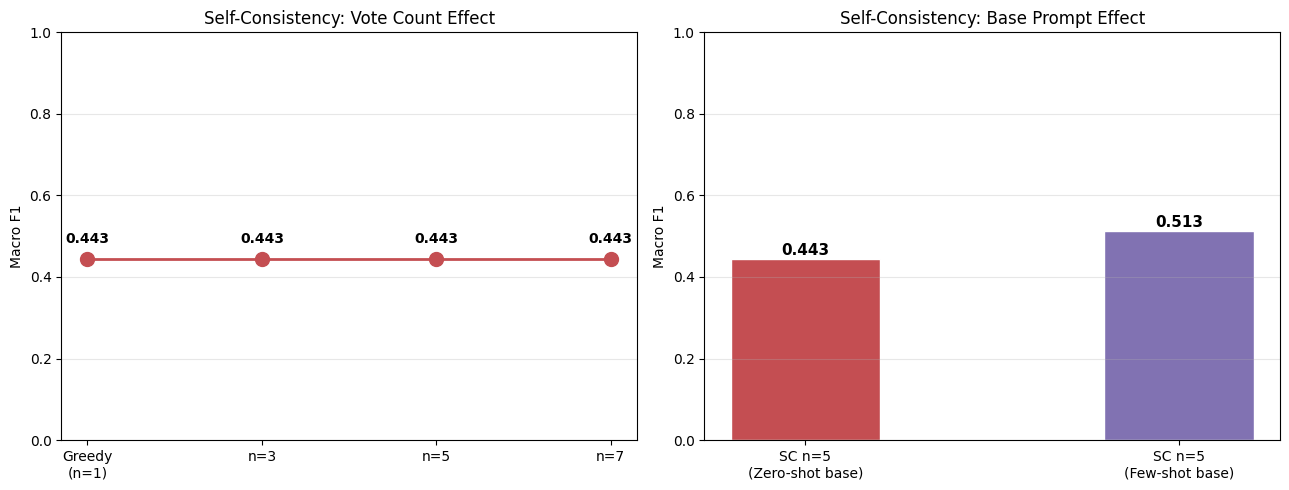

In [23]:
# Cell 19: Self-consistency ablation — vote count + base prompt effect

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Vote count effect
sc_names  = ["ZeroShot-Formal", "SelfCons-n3", "SelfCons-n5", "SelfCons-n7"]
sc_labels = ["Greedy\n(n=1)", "n=3", "n=5", "n=7"]
sc_vals   = [master_df.loc[n, "macro_f1"] if n in master_df.index else 0
             for n in sc_names]

axes[0].plot(sc_labels, sc_vals, marker="o", linewidth=2,
             color="#C44E52", markersize=10)
for x, y in zip(sc_labels, sc_vals):
    axes[0].annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                     xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Self-Consistency: Vote Count Effect")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

# Base prompt comparison for SC
sc_base_names  = ["SelfCons-n5", "SelfCons-FS-n5"]
sc_base_labels = ["SC n=5\n(Zero-shot base)", "SC n=5\n(Few-shot base)"]
sc_base_vals   = [master_df.loc[n, "macro_f1"] if n in master_df.index else 0
                  for n in sc_base_names]

bars = axes[1].bar(sc_base_labels, sc_base_vals,
                   color=["#C44E52","#8172B2"], edgecolor="white", width=0.4)
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Self-Consistency: Base Prompt Effect")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, sc_base_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_self_consistency_ablation.png", dpi=150)
plt.show()

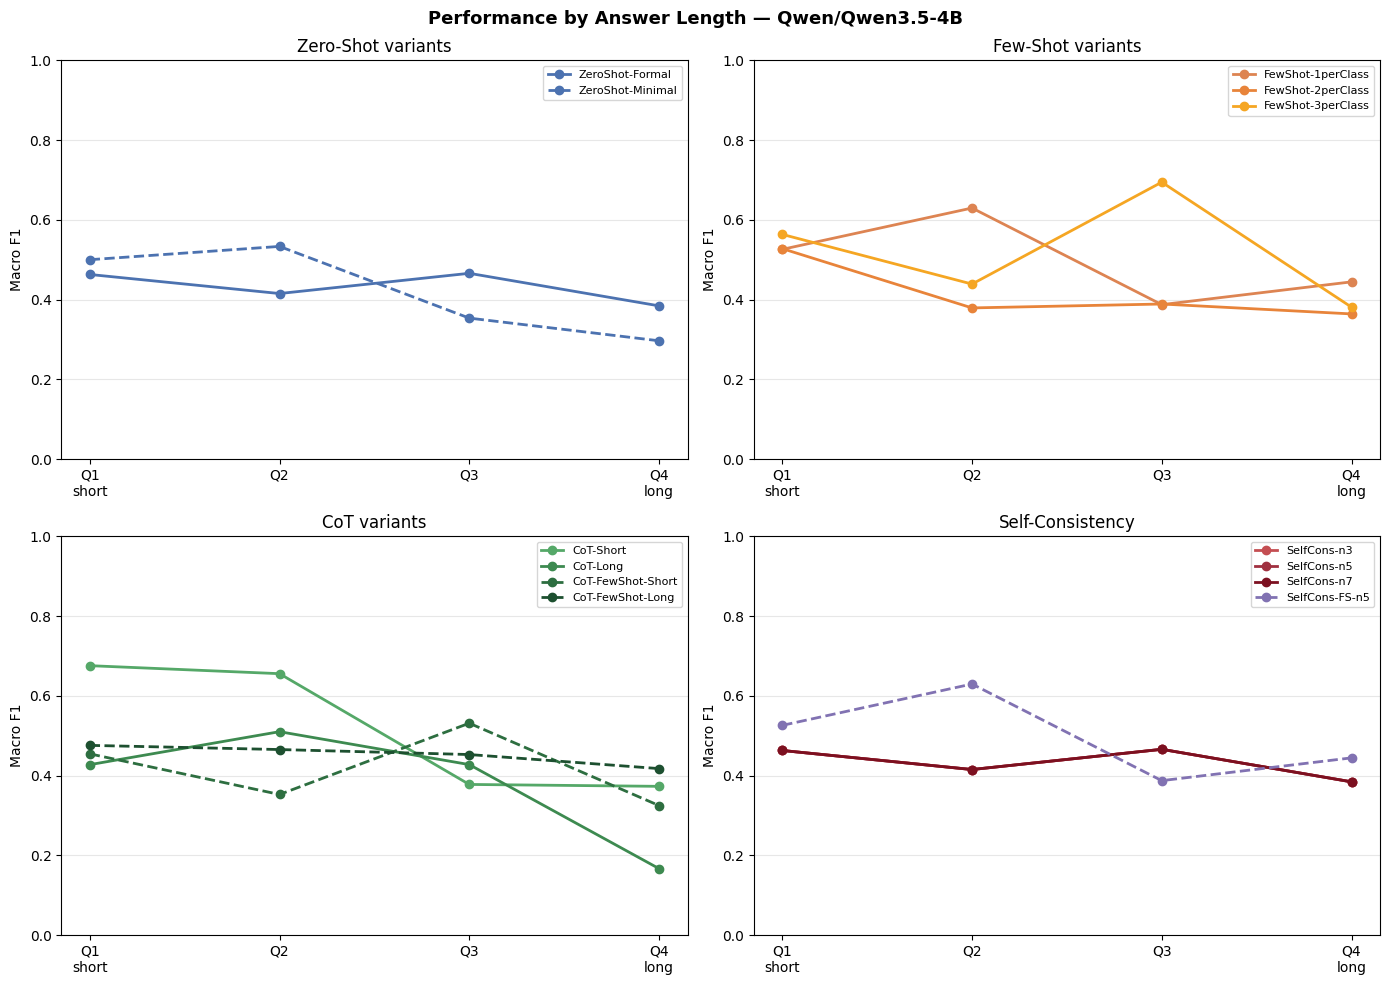

In [24]:
# Cell 20: Subgroup analysis by answer length

def subgroup_by_length(df_res):
    valid = df_res[df_res["predicted_label"] != "Unknown"].copy()
    valid["answer_len"] = valid["answer"].str.split().str.len()
    try:
        valid["quartile"] = pd.qcut(
            valid["answer_len"], q=4,
            labels=["Q1\nshort","Q2","Q3","Q4\nlong"],
            duplicates="drop"
        )
    except ValueError:
        return None
    rows = []
    for q in valid["quartile"].cat.categories:
        sub = valid[valid["quartile"] == q]
        f1  = f1_score(sub["label"], sub["predicted_label"],
                       average="macro", zero_division=0)
        rows.append({"quartile": str(q), "macro_f1": f1, "n": len(sub)})
    return pd.DataFrame(rows)

# All experiments on same plot grouped by strategy type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

groups = {
    "Zero-Shot variants":      (["ZeroShot-Formal","ZeroShot-Minimal"],
                                ["#4C72B0","#4C72B0"], ["-","--"]),
    "Few-Shot variants":       (["FewShot-1perClass","FewShot-2perClass","FewShot-3perClass"],
                                ["#DD8452","#E8843A","#F5A623"], ["-","-","-"]),
    "CoT variants":            (["CoT-Short","CoT-Long","CoT-FewShot-Short","CoT-FewShot-Long"],
                                ["#55A868","#3D8A50","#2D6E40","#1D5030"], ["-","-","--","--"]),
    "Self-Consistency":        (["SelfCons-n3","SelfCons-n5","SelfCons-n7","SelfCons-FS-n5"],
                                ["#C44E52","#A03040","#7C1020","#8172B2"], ["-","-","-","--"]),
}

for ax, (group_name, (exp_list, colors, styles)) in zip(axes.flatten(), groups.items()):
    for exp_name, color, style in zip(exp_list, colors, styles):
        if exp_name not in all_results:
            continue
        sg = subgroup_by_length(all_results[exp_name])
        if sg is not None:
            ax.plot(sg["quartile"], sg["macro_f1"], marker="o",
                    label=exp_name, color=color, linestyle=style, linewidth=2)
    ax.set_title(group_name)
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Performance by Answer Length — {MODEL_NAME}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_subgroup_length.png", dpi=150)
plt.show()

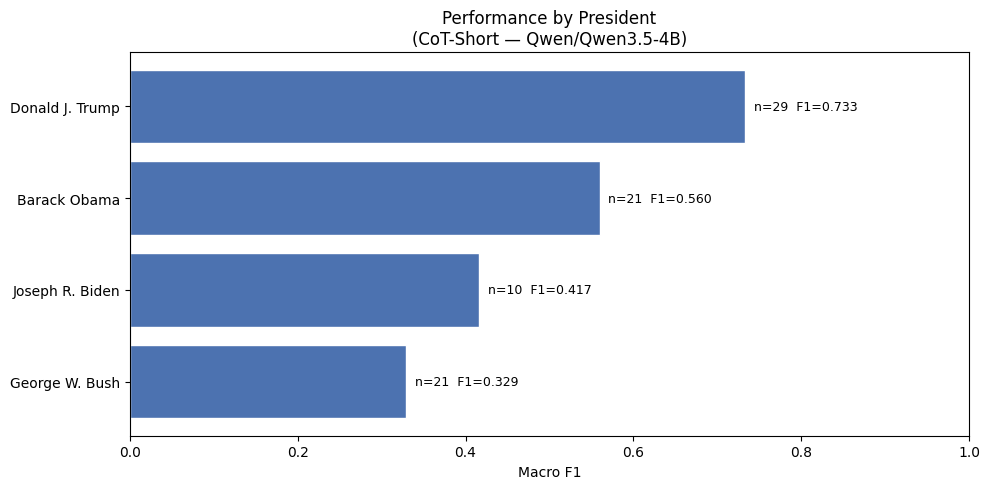

In [25]:
# Cell 21: Subgroup by president — best strategy only

best_df  = all_results[best_exp_name].copy()
valid    = best_df[best_df["predicted_label"] != "Unknown"]

pres_rows = []
for pres in valid["president"].dropna().unique():
    sub = valid[valid["president"] == pres]
    if len(sub) < 5:
        continue
    f1  = f1_score(sub["label"], sub["predicted_label"], average="macro", zero_division=0)
    acc = accuracy_score(sub["label"], sub["predicted_label"])
    pres_rows.append({"president": pres, "macro_f1": f1, "accuracy": acc, "n": len(sub)})

pres_df = pd.DataFrame(pres_rows).sort_values("macro_f1", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pres_df["president"], pres_df["macro_f1"],
               color="#4C72B0", edgecolor="white")
ax.set_xlabel("Macro F1")
ax.set_title(f"Performance by President\n({best_exp_name} — {MODEL_NAME})")
ax.set_xlim(0, 1)
for bar, row in zip(bars, pres_df.itertuples()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"n={row.n}  F1={row.macro_f1:.3f}",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_subgroup_president.png", dpi=150)
plt.show()


  CoT-Short
  Error rate : 33/81 (40.7%)

  Errors by true class:
label
Ambivalent         20
Clear Non-Reply    10
Clear Reply         3

  Confusion pairs:
label            predicted_label
Ambivalent       Clear Non-Reply    10
                 Clear Reply        10
Clear Non-Reply  Ambivalent          9
Clear Reply      Clear Non-Reply     3
Clear Non-Reply  Clear Reply         1

  Sample errors:

    True : Ambivalent
    Pred : Clear Reply
    Q    : Mr. President, you met a lot of leaders here; many were angry about the NSA story. Have you fixed th
    A    : Well, first of all, we have had a consistent, unbreakable bond between the leaders of Europe over the last several decades, and it's across many dimen
    Out  : The politician provides a detailed explanation of the ongoing diplomatic relationship, outlines specific steps taken to restore trust, and expresses confidence in the future of these partnerships, the

    True : Ambivalent
    Pred : Clear Reply
    Q    : Concer

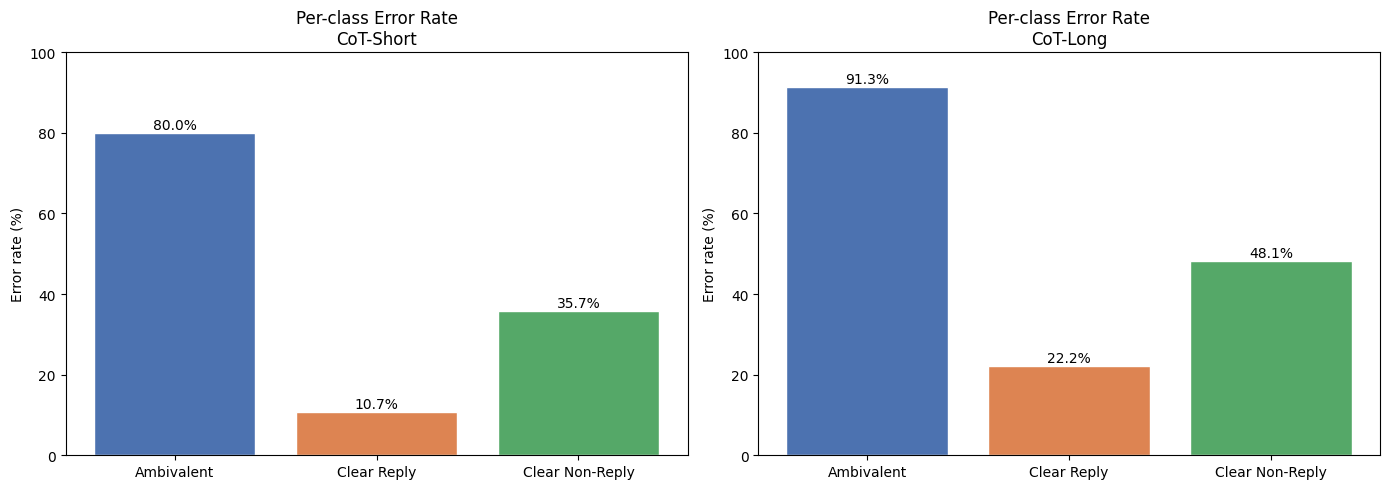

In [26]:
# Cell 22: Error analysis — best vs worst + per-class breakdown

best_exp  = master_df.index[0]
worst_exp = master_df.index[-1]

for exp_name in [best_exp, worst_exp]:
    df_res = all_results[exp_name]
    valid  = df_res[df_res["predicted_label"] != "Unknown"].copy()
    errors = valid[valid["label"] != valid["predicted_label"]]

    print(f"\n{'='*65}")
    print(f"  {exp_name}")
    print(f"  Error rate : {len(errors)}/{len(valid)} ({100*len(errors)/len(valid):.1f}%)")
    print(f"{'='*65}")
    print(f"\n  Errors by true class:\n{errors['label'].value_counts().to_string()}")
    print(f"\n  Confusion pairs:\n"
          f"{errors.groupby(['label','predicted_label']).size().sort_values(ascending=False).to_string()}")
    print(f"\n  Sample errors:")
    for _, row in errors.sample(min(5, len(errors)), random_state=SEED).iterrows():
        print(f"\n    True : {row['label']}")
        print(f"    Pred : {row['predicted_label']}")
        print(f"    Q    : {str(row['question'])[:100]}")
        print(f"    A    : {str(row['answer'])[:150]}")
        if "raw_output" in row and str(row["raw_output"]).strip():
            print(f"    Out  : {str(row['raw_output'])[:200]}")

# Per-class error rate chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, exp_name in zip(axes, [best_exp, worst_exp]):
    df_res = all_results[exp_name]
    valid  = df_res[df_res["predicted_label"] != "Unknown"].copy()
    errors = valid[valid["label"] != valid["predicted_label"]]
    err_by_class = []
    for label in LABELS:
        total = (valid["label"] == label).sum()
        wrong = ((valid["label"] == label) & (valid["predicted_label"] != label)).sum()
        err_by_class.append(wrong / total * 100 if total > 0 else 0)
    bars = ax.bar(LABELS, err_by_class,
                  color=["#4C72B0","#DD8452","#55A868"], edgecolor="white")
    ax.set_ylabel("Error rate (%)")
    ax.set_title(f"Per-class Error Rate\n{exp_name}")
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, err_by_class):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_error_analysis.png", dpi=150)
plt.show()

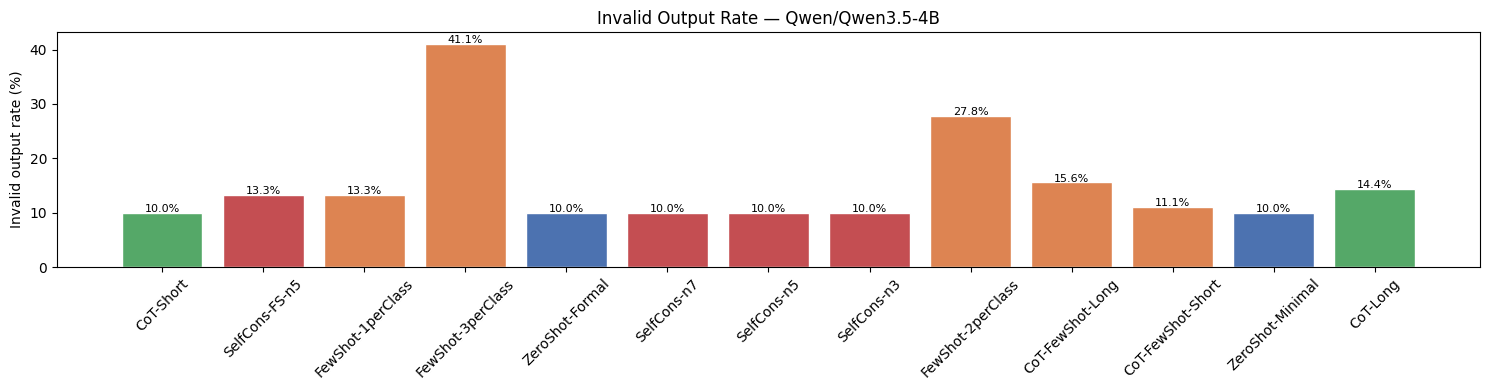

In [27]:
# Cell 23: Invalid output rates

inv_rates  = {n: m["n_invalid"] / len(val_subset) * 100
              for n, m in all_metrics.items()}
inv_series = pd.Series(inv_rates).reindex(master_df.index)

fig, ax = plt.subplots(figsize=(15, 4))
colors_inv = []
for n in inv_series.index:
    if "ZeroShot" in n:      colors_inv.append("#4C72B0")
    elif "FewShot" in n:     colors_inv.append("#DD8452")
    elif "CoT" in n:         colors_inv.append("#55A868")
    else:                    colors_inv.append("#C44E52")

bars = ax.bar(inv_series.index, inv_series.values,
              color=colors_inv, edgecolor="white")
ax.set_ylabel("Invalid output rate (%)")
ax.set_title(f"Invalid Output Rate — {MODEL_NAME}")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, inv_series.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_invalid_rates.png", dpi=150)
plt.show()

In [28]:
# Cell 24: Run best experiment on full test set

best_exp_name = master_df.index[0]
best_config   = next(e for e in EXPERIMENTS if e[0] == best_exp_name)
_, best_builder, best_max_tok, best_is_sc, best_n_sc = best_config

print(f"Best experiment : {best_exp_name}")
print(f"Macro F1 (val)  : {master_df.loc[best_exp_name,'macro_f1']:.4f}")
print(f"Running on full test set ({len(test_df)} rows)...")

if best_is_sc:
    test_results = run_self_consistency(
        test_df, best_builder, n_samples=best_n_sc, temperature=0.7
    )
else:
    test_results = run_inference(
        test_df, best_builder, max_new_tokens=best_max_tok
    )

print(f"\nPrediction distribution:\n{test_results['predicted_label'].value_counts()}")

Best experiment : CoT-Short
Macro F1 (val)  : 0.5250
Running on full test set (308 rows)...
  30/308 done | invalid: 1
  60/308 done | invalid: 4
  90/308 done | invalid: 4
  120/308 done | invalid: 6
  150/308 done | invalid: 9
  180/308 done | invalid: 9
  210/308 done | invalid: 11
  240/308 done | invalid: 13
  270/308 done | invalid: 16
  300/308 done | invalid: 17
Done. Invalid: 17/308 (5.5%)

Prediction distribution:
predicted_label
Clear Reply        196
Clear Non-Reply     72
Ambivalent          23
Unknown             17
Name: count, dtype: int64


In [29]:
# Cell 25: Save submission CSV

MAJORITY_CLASS = train_df["label"].value_counts().idxmax()
final_labels   = test_results["predicted_label"].replace("Unknown", MAJORITY_CLASS)

id_col = "index" if "index" in test_df.columns else None
submission = pd.DataFrame({
    "Id":    test_df[id_col].values if id_col else range(len(test_df)),
    "Predicted": final_labels.values,
})

fname = f"submission.csv"
submission.to_csv(fname, index=False)
print(f"Saved  : {fname}")
print(f"Rows   : {len(submission)}")
print(f"Labels : {submission['Predicted'].value_counts().to_dict()}")
print(submission.head())

Saved  : submission.csv
Rows   : 308
Labels : {'Clear Reply': 196, 'Clear Non-Reply': 72, 'Ambivalent': 40}
   Id        Predicted
0   0  Clear Non-Reply
1   1      Clear Reply
2   2       Ambivalent
3   3      Clear Reply
4   4      Clear Reply


In [30]:
# Cell 26: Final summary

print("=" * 70)
print(f"  MODEL    : {MODEL_NAME}")
print(f"  NOTEBOOK : {NOTEBOOK_ID}")
print(f"  Eval set : val_subset ({len(val_subset)} samples, "
      f"{len(val_subset)//len(LABELS)} per class)")
print("=" * 70)
print(f"\n  Total experiments : {len(EXPERIMENTS)}")
print(f"\n  TOP 5:")
for i, (name, row) in enumerate(master_df.head(5).iterrows()):
    print(f"    {i+1}. {name:28s} Macro F1={row['macro_f1']:.4f}  "
          f"Acc={row['accuracy']:.4f}  Invalid={row['n_invalid']}")
print(f"\n  BOTTOM 3:")
for i, (name, row) in enumerate(master_df.tail(3).iterrows()):
    print(f"       {name:28s} Macro F1={row['macro_f1']:.4f}")
print(f"\n  Best overall  : {best_exp_name}")
print(f"  Submission    : {fname}  ({len(submission)} rows)")
print("=" * 70)
print("\nPlots saved:")
for suffix in [
    "all_experiments_macro_f1",
    "perclass_f1_heatmap",
    "confusion_matrices",
    "shot_count_effect",
    "cot_ablation",
    "self_consistency_ablation",
    "subgroup_length",
    "subgroup_president",
    "error_analysis",
    "invalid_rates",
]:
    print(f"  {NOTEBOOK_ID}_{suffix}.png")

  MODEL    : Qwen/Qwen3.5-4B
  NOTEBOOK : qwen3.5-4B
  Eval set : val_subset (90 samples, 30 per class)

  Total experiments : 13

  TOP 5:
    1. CoT-Short                    Macro F1=0.5250  Acc=0.5333  Invalid=9.0
    2. SelfCons-FS-n5               Macro F1=0.5129  Acc=0.5000  Invalid=12.0
    3. FewShot-1perClass            Macro F1=0.5129  Acc=0.5000  Invalid=12.0
    4. FewShot-3perClass            Macro F1=0.4465  Acc=0.3556  Invalid=37.0
    5. ZeroShot-Formal              Macro F1=0.4430  Acc=0.4222  Invalid=9.0

  BOTTOM 3:
       CoT-FewShot-Short            Macro F1=0.4250
       ZeroShot-Minimal             Macro F1=0.4174
       CoT-Long                     Macro F1=0.4043

  Best overall  : CoT-Short
  Submission    : submission.csv  (308 rows)

Plots saved:
  qwen3.5-4B_all_experiments_macro_f1.png
  qwen3.5-4B_perclass_f1_heatmap.png
  qwen3.5-4B_confusion_matrices.png
  qwen3.5-4B_shot_count_effect.png
  qwen3.5-4B_cot_ablation.png
  qwen3.5-4B_self_consistency_ablat